In [20]:
'''
  This program reads the data from the price of gasoline csv file 
    and uses only the numeric data.
  Each line of the file has the year, followed by 12 months of gasoline prices.
  We put the numeric fields in a NumPy array and use the data for numeric operations.

  The outputs of the program are the averages of each month across the years
    and the averages for each year.
'''

import csv
import numpy as np

#infile = 'Price_of_Gasoline.XL.csv'


In [21]:
# create new empty lists:  years and prices come from data
yearsList = []
pricesList = []
# names of months for labeling results
monthList = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']


In [23]:
# read the data
with open('Price_of_Gasoline.XL.csv', 'r') as csvfile:
    # the csv file reader returns a list of the csv items on each line - note delimiter is comma
    priceReader = csv.reader(csvfile,  dialect='excel', delimiter=',')

    # from each line, a list of row items, make separate lists for years and for the prices
    for line in priceReader:
      # skip lines without data
        #Add additional argument for lines in excess of 2000
      if line[0] == '' or line[0].startswith('Price') or line[0].startswith('Year') or line[0] > '2000':
          continue
      else:
          try:
            # add the year to list
            yearsList.append(line[0])
            # append the prices (as strings) to the list
            pricesList.append(line[1:])
          except IndexError:
            print ('Error: ', line)
csvfile.close()

In [24]:
print ("Read", len(yearsList), "years of prices")

# make a numpy array for the strings
data = np.array(pricesList)
print('Shape of Prices data', data.shape)


Read 25 years of prices
Shape of Prices data (25, 12)


In [27]:
# convert the empty strings to strings of zeros, using a Boolean mask to find empty strings
data[data == ''] = '0'

# now we can convert the whole thing to float without getting conversion errors for the empty strings
prices = data.astype(float)


In [28]:
#print(prices)

# compute the average price for each month (or use mean)
# sum along the columns
monthTotalPrices = np.sum(prices, axis = 0)
# divide by number of years to get average
monthAveragePrices = monthTotalPrices / len(yearsList)

#print(monthAveragePrices)
print ("\nAverage gas price for each month\n")

# print the average price for each month
for i, mon in enumerate(monthList):
	print (mon, ':', monthAveragePrices[i])

# compute the average price for each year up to the last one with missing data
# sum along the rows
yearTotalPrices = np.sum(prices, axis = 1)
# divide by number of months to get average
yearAveragePrices = yearTotalPrices / 12




Average gas price for each month

Jan : 1.05316
Feb : 1.0490399999999998
Mar : 1.04964
Apr : 1.0727600000000002
May : 1.09616
Jun : 1.11276
Jul : 1.1088799999999999
Aug : 1.11056
Sep : 1.1160400000000001
Oct : 1.1116400000000002
Nov : 1.1075199999999998
Dec : 1.0962800000000004


In [29]:
#print(monthAveragePrices)
print ("\nAverage gas price for each year\n")

 
for i, year in enumerate(yearsList[ :-1]):
  print (year ,':', yearAveragePrices[i])

# or display the monthly averages as a simple plot



Average gas price for each year

1976 : 0.6143333333333333
1977 : 0.6563333333333333
1978 : 0.6702500000000001
1979 : 0.90325
1980 : 1.2451666666666668
1981 : 1.3782499999999998
1982 : 1.2954999999999999
1983 : 1.2411666666666668
1984 : 1.2122499999999998
1985 : 1.20175
1986 : 0.9274166666666667
1987 : 0.9484166666666666
1988 : 0.9461666666666667
1989 : 1.0221666666666667
1990 : 1.1643333333333334
1991 : 1.1400833333333333
1992 : 1.1264999999999998
1993 : 1.1079166666666667
1994 : 1.1118333333333332
1995 : 1.1471666666666664
1996 : 1.2309166666666667
1997 : 1.2336666666666665
1998 : 1.0593333333333335
1999 : 1.1650833333333332


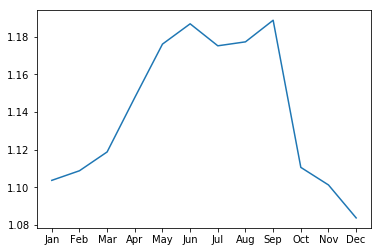

In [10]:
%matplotlib inline
import matplotlib.pyplot as pp

x = np.arange(12)
pp.xticks(x,monthList)
pp.plot(x, monthAveragePrices)
pp.show()


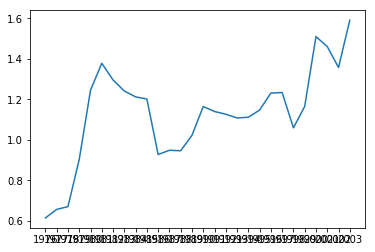

In [11]:
# or we can also display the years with a simple plot
x = np.arange(len(yearsList)-1)
pp.xticks(x,yearsList)
pp.plot(x, yearAveragePrices[:-1])
pp.show()

# Done!